In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import pandas as pd
import numpy as np
%matplotlib inline

In [3]:
X,y= make_blobs(n_samples=1000,centers=3,n_features=2)

In [4]:
X

array([[ 11.45076649,   0.35861914],
       [  0.49385286,  -4.78264276],
       [-10.54570144,  -4.45064306],
       ...,
       [ -9.19571252,  -1.65171707],
       [  7.80854035,   0.66873969],
       [ -1.3432608 ,  -0.97346621]], shape=(1000, 2))

In [5]:
y

array([0, 1, 2, 1, 0, 2, 2, 2, 2, 0, 2, 2, 2, 0, 1, 1, 1, 0, 1, 0, 2, 1,
       2, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 2, 0, 2, 1, 2, 2, 0, 1, 2, 0, 1,
       1, 1, 2, 1, 0, 0, 0, 1, 0, 1, 1, 2, 1, 1, 2, 1, 2, 1, 2, 1, 0, 1,
       2, 0, 0, 1, 2, 0, 2, 1, 1, 2, 0, 2, 1, 1, 1, 0, 1, 2, 2, 0, 2, 2,
       2, 2, 2, 1, 1, 0, 0, 0, 0, 1, 1, 2, 1, 2, 0, 2, 1, 2, 1, 0, 2, 0,
       2, 2, 2, 0, 2, 1, 1, 2, 0, 0, 2, 1, 1, 1, 0, 2, 2, 1, 1, 1, 2, 2,
       1, 2, 0, 1, 2, 2, 2, 1, 2, 0, 2, 1, 0, 2, 1, 1, 1, 0, 2, 1, 0, 2,
       2, 2, 1, 0, 0, 2, 1, 0, 0, 2, 2, 1, 1, 0, 1, 1, 1, 2, 2, 1, 1, 2,
       2, 0, 2, 2, 0, 0, 1, 0, 0, 2, 2, 1, 0, 2, 0, 2, 1, 2, 2, 1, 2, 2,
       0, 0, 1, 2, 0, 0, 0, 1, 0, 1, 0, 0, 2, 2, 0, 0, 1, 2, 1, 0, 0, 0,
       0, 1, 0, 0, 1, 1, 1, 2, 0, 2, 1, 2, 1, 2, 0, 1, 2, 1, 0, 1, 1, 2,
       2, 0, 0, 1, 2, 1, 0, 0, 2, 2, 1, 2, 2, 0, 1, 2, 0, 0, 1, 2, 1, 2,
       2, 1, 2, 2, 1, 1, 0, 1, 1, 1, 0, 2, 0, 0, 2, 1, 0, 1, 1, 0, 2, 0,
       1, 2, 2, 1, 1, 0, 1, 2, 2, 0, 0, 1, 0, 1, 1,

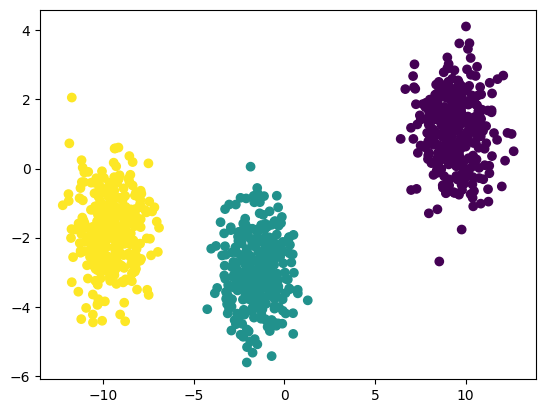

In [7]:
plt.scatter(X[:,0],X[:,1],c=y)

In [9]:
## standarization--feature scaling technique

from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [10]:
from sklearn.model_selection import train_test_split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.33, random_state=42)

In [12]:
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [13]:
from sklearn.cluster import KMeans

In [14]:
## elbow method to select k value
wcss=[]
for k in range(1,11):
    kmeans=KMeans(n_clusters=k,init="k-means++")
    kmeans.fit(X_train_scaled)
    wcss.append(kmeans.inertia_)

In [15]:
wcss

[1339.999999999999,
 326.6187647251858,
 177.6097340194359,
 142.76866517364306,
 107.96046342282965,
 97.656312679943,
 61.78597108643164,
 51.003775749120294,
 42.74554741205152,
 38.53452681404152]

ConversionError: Failed to convert value(s) to axis units: 'Number of clusters'

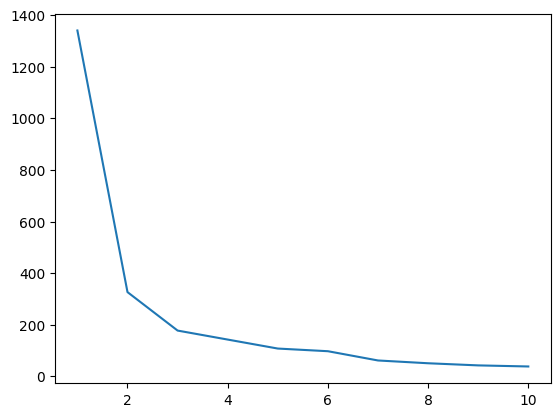

In [16]:
## plot elbow curve
plt.plot(range(1,11),wcss)
plt.xticks("Number of clusters")
plt.ylabel("wcss")
plt.show()

In [17]:
kmeans=KMeans(n_clusters=3,init="k-means++")

In [19]:
kmeans.fit_predict(X_train_scaled)

array([1, 2, 1, 2, 1, 1, 2, 1, 1, 1, 1, 0, 2, 2, 1, 1, 2, 0, 2, 2, 1, 1,
       0, 0, 1, 2, 0, 2, 2, 1, 0, 1, 0, 1, 2, 1, 1, 2, 1, 1, 0, 1, 2, 2,
       2, 1, 1, 0, 2, 0, 1, 2, 2, 1, 1, 0, 2, 0, 2, 1, 2, 2, 1, 0, 2, 0,
       0, 0, 2, 2, 1, 1, 1, 0, 1, 2, 0, 2, 0, 2, 2, 0, 2, 2, 0, 2, 2, 1,
       0, 2, 0, 0, 2, 1, 1, 2, 2, 0, 2, 0, 1, 2, 1, 1, 2, 2, 0, 2, 2, 2,
       1, 0, 2, 1, 1, 1, 1, 2, 2, 1, 1, 0, 1, 2, 1, 0, 1, 0, 2, 2, 0, 1,
       1, 0, 2, 0, 2, 2, 0, 1, 0, 0, 2, 2, 0, 2, 1, 0, 0, 1, 2, 1, 2, 2,
       1, 0, 1, 2, 1, 1, 0, 1, 0, 0, 1, 2, 2, 1, 1, 2, 2, 1, 2, 1, 2, 0,
       2, 2, 0, 1, 2, 1, 1, 0, 0, 1, 1, 2, 2, 2, 0, 0, 2, 2, 2, 1, 0, 1,
       1, 1, 1, 1, 2, 2, 0, 1, 2, 2, 1, 0, 1, 0, 2, 2, 2, 1, 1, 0, 1, 2,
       0, 1, 1, 0, 1, 2, 0, 0, 2, 1, 0, 0, 0, 0, 2, 1, 0, 0, 1, 0, 1, 1,
       2, 1, 2, 0, 2, 1, 0, 1, 0, 1, 1, 2, 2, 2, 1, 2, 2, 2, 0, 2, 0, 2,
       2, 2, 2, 2, 2, 0, 1, 0, 0, 1, 0, 0, 1, 0, 2, 1, 1, 0, 1, 0, 0, 2,
       1, 2, 0, 0, 1, 1, 1, 2, 0, 2, 1, 0, 1, 0, 2,

In [20]:
y_pred=kmeans.predict(X_test_scaled)

In [21]:
y_pred

array([2, 1, 1, 1, 0, 2, 0, 1, 0, 2, 2, 1, 0, 1, 0, 1, 1, 0, 0, 2, 0, 0,
       2, 1, 2, 0, 2, 0, 1, 2, 2, 0, 0, 1, 0, 1, 0, 2, 2, 0, 2, 1, 1, 2,
       0, 1, 2, 0, 1, 0, 2, 1, 2, 1, 0, 1, 2, 2, 2, 0, 1, 0, 1, 1, 0, 0,
       0, 1, 2, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 2, 0, 2, 2, 1, 0, 1, 1, 2,
       2, 0, 2, 1, 1, 1, 2, 2, 0, 2, 0, 0, 0, 2, 1, 0, 1, 0, 0, 2, 0, 1,
       0, 0, 2, 0, 2, 1, 1, 0, 1, 2, 0, 2, 1, 0, 0, 2, 1, 1, 2, 1, 2, 1,
       0, 2, 0, 2, 2, 2, 0, 2, 0, 0, 2, 0, 2, 2, 1, 1, 1, 1, 0, 1, 1, 0,
       1, 2, 2, 0, 2, 2, 0, 1, 2, 1, 1, 0, 1, 1, 2, 1, 1, 1, 2, 2, 0, 2,
       2, 1, 2, 2, 1, 2, 2, 0, 0, 2, 0, 1, 1, 0, 0, 2, 1, 1, 1, 2, 0, 1,
       0, 0, 1, 1, 0, 0, 0, 2, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1,
       2, 2, 0, 1, 1, 0, 2, 1, 2, 0, 2, 1, 0, 2, 2, 1, 2, 1, 0, 1, 0, 1,
       0, 0, 0, 1, 1, 2, 2, 0, 0, 0, 2, 2, 1, 0, 0, 0, 2, 2, 2, 2, 0, 2,
       1, 1, 2, 1, 0, 0, 2, 1, 0, 2, 1, 1, 2, 1, 1, 0, 2, 0, 0, 0, 2, 1,
       2, 0, 0, 1, 0, 1, 2, 0, 0, 2, 0, 0, 2, 2, 0,

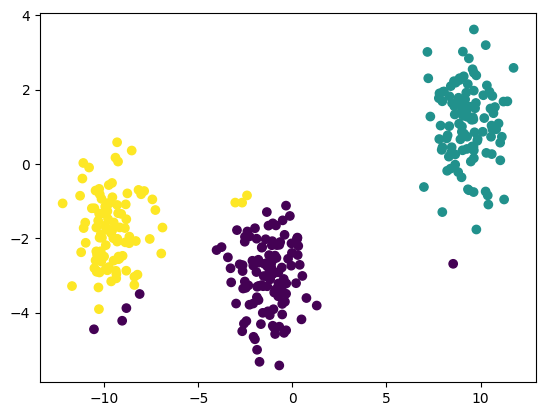

In [22]:
plt.scatter(X_test[:,0],X_test[:,1],c=y_pred)

In [ ]:
## validating the k value
##kneelocator
## silhoutee scoring
